In [1]:
# setup visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Configure display
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" All libraries imported successfully")

 All libraries imported successfully


In [2]:
# Load cleaned data from LOT-001
df = pd.read_csv('../data/france_wines_type1_clean.csv')

print(f"📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column names and types:")
print(df.dtypes)
print(f"\n No missing values: {df.isnull().sum().sum() == 0}")

📊 Dataset shape: 20,000 rows × 12 columns

📋 Column names and types:
wine                     object
winery                   object
vintage_year            float64
vintage_rating          float64
vintage_rating_count      int64
price_availability      float64
structure_acidity       float64
structure_intensity     float64
structure_sweetness     float64
structure_tannin        float64
region                   object
grapes                   object
dtype: object

 No missing values: True


In [3]:
"""
LOT-003-1: Data Preparation - ADVANCED TARGET ENCODING (GROUPED BY WINE)
=========================================================================
Transforms region into 4 statistical features with GROUPED SPLIT to avoid leakage
Split randomly by wine_id so all vintages of same wine stay in same split
"""

import pandas as pd
import numpy as np
import os
import pickle

# Create directories
os.makedirs('../data/processed', exist_ok=True)

print("=" * 80)
print("🍷 LOT-003-1: Advanced Target Encoding (GROUPED SPLIT)")
print("=" * 80)

# ============================================================================
# 1. LOAD & SELECT FEATURES
# ============================================================================
print("\n📂 Loading data...")

df = pd.read_csv('../data/france_wines_type1_clean.csv')
df = df[df['price_availability'] < 100]#.sample(n=10000, random_state=42)

features_to_drop = [
    'wine', 'winery', 'price_availability', 'vintage_rating_count',
    'grapes', 'structure_intensity', 'structure_sweetness'
]
df_selected = df.drop(columns=features_to_drop)

print(f"✅ Loaded {df_selected.shape[0]:,} wines")

# ============================================================================
# 2. GROUPED SPLIT (BY WINE_ID) - NO LEAKAGE!
# ============================================================================
print("\n✂️  GROUPED SPLIT by wine_id (random)...")

# Create wine_id if not exists (wine + winery combo)
if 'wine_id' not in df.columns:
    df['wine_id'] = df['wine'].astype(str) + '_' + df['winery'].astype(str)
    df_selected['wine_id'] = df.loc[df_selected.index, 'wine_id']

# Analyze year distribution
year_counts = df_selected['vintage_year'].value_counts().sort_index()
print(f"\n📊 Vintage year distribution:")
print(f"   Years range: {year_counts.index.min():.0f} - {year_counts.index.max():.0f}")
print(f"   Most common years: {year_counts.head(5).to_dict()}")

# Group by wine_id to understand structure
wine_year_stats = df_selected.groupby('wine_id').agg({
    'vintage_year': ['min', 'max', 'median', 'count']
}).reset_index()
wine_year_stats.columns = ['wine_id', 'year_min', 'year_max', 'year_median', 'n_vintages']

print(f"\n🍷 Unique wines: {len(wine_year_stats)}")
print(f"   Wines with multiple vintages: {(wine_year_stats['n_vintages'] > 1).sum()}")
print(f"   Average vintages per wine: {wine_year_stats['n_vintages'].mean():.1f}")
print(f"   Max vintages for one wine: {wine_year_stats['n_vintages'].max()}")

# RANDOM SPLIT by wine_id (60/20/20)
wine_ids = df_selected['wine_id'].unique()
np.random.seed(42)
wine_ids_shuffled = wine_ids.copy()
np.random.shuffle(wine_ids_shuffled)

n_wines = len(wine_ids_shuffled)
train_wine_cutoff = int(n_wines * 0.60)
val_wine_cutoff = int(n_wines * 0.80)

train_wines = set(wine_ids_shuffled[:train_wine_cutoff])
val_wines = set(wine_ids_shuffled[train_wine_cutoff:val_wine_cutoff])
test_wines = set(wine_ids_shuffled[val_wine_cutoff:])

print(f"\n🎯 Split by wine groups (RANDOM):")
print(f"   Train wines: {len(train_wines)} unique wines")
print(f"   Val wines:   {len(val_wines)} unique wines")
print(f"   Test wines:  {len(test_wines)} unique wines")

# Create splits based on wine_id
train_mask = df_selected['wine_id'].isin(train_wines)
val_mask = df_selected['wine_id'].isin(val_wines)
test_mask = df_selected['wine_id'].isin(test_wines)

df_train = df_selected[train_mask].copy()
df_val = df_selected[val_mask].copy()
df_test = df_selected[test_mask].copy()

# Extract X and y
y_train = df_train['vintage_rating']
y_val = df_val['vintage_rating']
y_test = df_test['vintage_rating']

X_train = df_train.drop(columns=['vintage_rating'])
X_val = df_val.drop(columns=['vintage_rating'])
X_test = df_test.drop(columns=['vintage_rating'])

# Reset indices
for data in [X_train, X_val, X_test, y_train, y_val, y_test]:
    data.reset_index(drop=True, inplace=True)

print(f"\n✅ Split sizes:")
print(f"   Train: {len(X_train):,} samples ({len(X_train)/len(df_selected)*100:.1f}%)")
print(f"   Val:   {len(X_val):,} samples ({len(X_val)/len(df_selected)*100:.1f}%)")
print(f"   Test:  {len(X_test):,} samples ({len(X_test)/len(df_selected)*100:.1f}%)")

# Verify year distributions (should be similar across splits since random)
print(f"\n✅ Year ranges (random split, so similar distributions expected):")
print(f"   Train: {X_train['vintage_year'].min():.0f} - {X_train['vintage_year'].max():.0f} "
      f"(mean: {X_train['vintage_year'].mean():.1f})")
print(f"   Val:   {X_val['vintage_year'].min():.0f} - {X_val['vintage_year'].max():.0f} "
      f"(mean: {X_val['vintage_year'].mean():.1f})")
print(f"   Test:  {X_test['vintage_year'].min():.0f} - {X_test['vintage_year'].max():.0f} "
      f"(mean: {X_test['vintage_year'].mean():.1f})")

# Check for wine leakage (should be ZERO!)
wines_train = set(X_train['wine_id'].unique())
wines_val = set(X_val['wine_id'].unique())
wines_test = set(X_test['wine_id'].unique())

leak_val = wines_val & wines_train
leak_test = wines_test & wines_train
leak_val_test = wines_val & wines_test

print(f"\n✅ Wine leakage check (should be ZERO!):")
print(f"   Wines in both Train & Val:  {len(leak_val)} ✓")
print(f"   Wines in both Train & Test: {len(leak_test)} ✓")
print(f"   Wines in both Val & Test:   {len(leak_val_test)} ✓")

if len(leak_val) + len(leak_test) + len(leak_val_test) == 0:
    print(f"   🎉 PERFECT! No wine appears in multiple splits!")

# ============================================================================
# 3. ADVANCED TARGET ENCODING (4 features per region)
# ============================================================================
print("\n" + "=" * 80)
print("🎯 Advanced target encoding: region → 4 statistical features")
print("=" * 80)

numerical = ['vintage_year', 'structure_acidity', 'structure_tannin']

# Calculate regional statistics from TRAINING SET ONLY
print("\n   Computing regional statistics from training data...")

region_stats = X_train.groupby('region').apply(
    lambda x: pd.Series({
        'mean': y_train.iloc[x.index].mean(),
        'median': y_train.iloc[x.index].median(),
        'std': y_train.iloc[x.index].std(),
        'count': len(x)
    })
).reset_index()

# Global statistics for unseen regions
global_mean = y_train.mean()
global_median = y_train.median()
global_std = y_train.std()
global_count = 1  # Minimal confidence

print(f"   ✓ Computed statistics for {len(region_stats)} regions")
print(f"   Global fallback: mean={global_mean:.3f}, median={global_median:.3f}, std={global_std:.3f}")

# Bayesian smoothing parameter

from target_encoder import TargetEncoder

k = 20  # Smoothing factor (higher = more regularization)
encoder = TargetEncoder(region_stats, global_mean, global_median, global_std, global_count, k)
with open('./models/encoders/target_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("✅ Saved region encoder → target_encoder.pkl")

# Apply encoding
with open('./models/encoders/target_encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)
print(encoder.k)  # should output 20

X_train_proc = encoder.transform(X_train, numerical)
X_val_proc = encoder.transform(X_val, numerical)
X_test_proc = encoder.transform(X_test, numerical)

print(f"✅ Encoded: {X_train_proc.shape[1]} features")
print(f"   Original numerical: {numerical}")
print(f"   New region features: ['region_mean_smoothed', 'region_median', 'region_count_log', 'region_std']")

# ============================================================================
# 4. VERIFICATION
# ============================================================================
print("\n" + "=" * 80)
print("🔍 Feature Statistics")
print("=" * 80)

print("\n📊 Regional features (training set):")
for col in ['region_mean_smoothed', 'region_median', 'region_count_log', 'region_std']:
    print(f"   {col:25s}: [{X_train_proc[col].min():.3f}, {X_train_proc[col].max():.3f}] "
          f"(mean: {X_train_proc[col].mean():.3f})")

print("\n📋 First 5 samples (train):")
print(X_train_proc.head().to_string())

print("\n📋 Rating distribution:")
print(f"   Train: mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"   Val:   mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"   Test:  mean={y_test.mean():.3f}, std={y_test.std():.3f}")

# ============================================================================
# 5. SAVE PROCESSED DATA
# ============================================================================
print("\n" + "=" * 80)
print("💾 Saving Processed Data")
print("=" * 80)

# Convert to numpy arrays
X_train_final = X_train_proc.values
X_val_final = X_val_proc.values
X_test_final = X_test_proc.values

# Save as numpy arrays
np.save('../data/processed/X_train_te.npy', X_train_final)
np.save('../data/processed/X_val_te.npy', X_val_final)
np.save('../data/processed/X_test_te.npy', X_test_final)
np.save('../data/processed/y_train_te.npy', y_train.values)
np.save('../data/processed/y_val_te.npy', y_val.values)
np.save('../data/processed/y_test_te.npy', y_test.values)

print(f"✅ Saved 6 numpy arrays to ../data/processed/*_te.npy")

# Save metadata
import json

metadata = {
    'split_method': 'grouped_random',
    'feature_names': list(X_train_proc.columns),
    'n_features': X_train_proc.shape[1],
    'numerical_features': numerical,
    'region_features': ['region_mean_smoothed', 'region_median', 'region_count_log', 'region_std'],
    'encoding_params': {
        'k_smoothing': k,
        'global_mean': float(global_mean),
        'global_median': float(global_median),
        'global_std': float(global_std)
    },
    'split_info': {
        'train_wines': len(train_wines),
        'val_wines': len(val_wines),
        'test_wines': len(test_wines),
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'zero_leakage': len(leak_val) + len(leak_test) + len(leak_val_test) == 0
    }
}

with open('../data/processed/metadata_grouped.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Save regional statistics for future use
region_stats.to_csv('../data/processed/region_stats_grouped.csv', index=False)

print(f"✅ Saved metadata_grouped.json and region_stats_grouped.csv")

print("\n" + "=" * 80)
print(f"✅ COMPLETE! Final shape: {X_train_final.shape}")
print("=" * 80)
print(f"\n📊 Summary:")
print(f"   Split method: GROUPED RANDOM (by wine_id)")
print(f"   Train: {len(X_train):,} samples from {len(train_wines)} unique wines")
print(f"   Val:   {len(X_val):,} samples from {len(val_wines)} unique wines")
print(f"   Test:  {len(X_test):,} samples from {len(test_wines)} unique wines")
print(f"\n   Features ({X_train_final.shape[1]}): {list(X_train_proc.columns)}")
print(f"\n💡 Region encoded as 4 features capturing:")
print(f"   1. Quality (smoothed mean)")
print(f"   2. Robustness (median)")
print(f"   3. Confidence (log count)")
print(f"   4. Stability (std deviation)")
print(f"\n🎯 ZERO WINE OVERLAP between splits → No leakage!")
print(f"   Same wine stays in same split across all its vintages")
print("=" * 80)

🍷 LOT-003-1: Advanced Target Encoding (GROUPED SPLIT)

📂 Loading data...
✅ Loaded 14,698 wines

✂️  GROUPED SPLIT by wine_id (random)...

📊 Vintage year distribution:
   Years range: 1903 - 2024
   Most common years: {1903.0: 1, 1935.0: 1, 1955.0: 1, 1958.0: 1, 1959.0: 1}

🍷 Unique wines: 9989
   Wines with multiple vintages: 2747
   Average vintages per wine: 1.5
   Max vintages for one wine: 13

🎯 Split by wine groups (RANDOM):
   Train wines: 5993 unique wines
   Val wines:   1998 unique wines
   Test wines:  1998 unique wines

✅ Split sizes:
   Train: 9,020 samples (61.4%)
   Val:   2,800 samples (19.1%)
   Test:  2,878 samples (19.6%)

✅ Year ranges (random split, so similar distributions expected):
   Train: 1903 - 2024 (mean: 2016.3)
   Val:   1958 - 2024 (mean: 2017.1)
   Test:  1935 - 2024 (mean: 2016.3)

✅ Wine leakage check (should be ZERO!):
   Wines in both Train & Val:  0 ✓
   Wines in both Train & Test: 0 ✓
   Wines in both Val & Test:   0 ✓
   🎉 PERFECT! No wine appears

In [4]:
"""
LOT-003-2: Fast Model Training with Advanced Target Encoding - IMPROVED
========================================================================
Enhanced version with optimized grid search and comprehensive visualizations
"""

import numpy as np
import pandas as pd
import joblib
import time
from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import json

import warnings
import os
import xgboost

warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("🍷 LOT-003-2: Fast Model Training (Advanced Target Encoding) - IMPROVED")
print("=" * 80)
print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("📂 Loading advanced target encoded data...")

X_train = np.load('../data/processed/X_train_te.npy')
X_val = np.load('../data/processed/X_val_te.npy')
X_test = np.load('../data/processed/X_test_te.npy')
y_train = np.load('../data/processed/y_train_te.npy')
y_val = np.load('../data/processed/y_val_te.npy')
y_test = np.load('../data/processed/y_test_te.npy')

print(f"✅ Train: {X_train.shape[0]:,} × {X_train.shape[1]} features")
print(f"✅ Val:   {X_val.shape[0]:,} × {X_val.shape[1]} features")
print(f"✅ Test:  {X_test.shape[0]:,} × {X_test.shape[1]} features")

# Load feature names
with open('../data/processed/metadata_grouped.json', 'r') as f:
    metadata = json.load(f)
    feature_names = metadata['feature_names']

print(f"\n📊 Features: {feature_names}\n")

# ============================================================================
# 2. EVALUATION FUNCTION
# ============================================================================
def evaluate(y_true, y_pred, name="Model"):
    """Fast evaluation with key metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")

    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# ============================================================================
# 3. TRAIN MODELS (ENHANCED HYPERPARAMETERS)
# ============================================================================
results = []
models = {}
grid_results = {}

print("=" * 80)
print("🚀 Training Models")
print("=" * 80)

# --- Baseline: Linear Regression ---
print("\n1️⃣  Linear Regression")
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start

lr_metrics = evaluate(y_val, lr.predict(X_val), "Linear Regression (Val)")
results.append({'model': 'LinearRegression', **lr_metrics, 'time': lr_time})
models['LinearRegression'] = lr

# --- Ridge Regression (Enhanced Grid) ---
print("\n2️⃣  Ridge Regression (Enhanced)")
start = time.time()

# Grille plus fine avec plus de valeurs
ridge_alphas = np.logspace(-4, 4, 20)
ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': ridge_alphas},
    cv=5,  # Plus de folds pour meilleure estimation
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)
ridge_grid.fit(X_train, y_train)
ridge_time = time.time() - start

print(f"  Best alpha: {ridge_grid.best_params_['alpha']:.4e}")
ridge_metrics = evaluate(y_val, ridge_grid.predict(X_val), "Ridge (Val)")
results.append({'model': 'Ridge', **ridge_metrics, 'time': ridge_time})
models['Ridge'] = ridge_grid.best_estimator_
grid_results['Ridge'] = ridge_grid.cv_results_

# --- Random Forest (Enhanced Grid) ---
print("\n3️⃣  Random Forest (Enhanced)")
start = time.time()



rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [50, 100, 200, 300, 500],
        'max_depth': [5, 10, 15, 20, 50, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    n_iter=20,  # number of parameter settings to try
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

rf_random.fit(X_train, y_train)
rf_time = time.time() - start

print(f"  Best params: {rf_random.best_params_}")
rf_metrics = evaluate(y_val, rf_random.predict(X_val), "Random Forest (Val)")
results.append({'model': 'RandomForest', **rf_metrics, 'time': rf_time})
models['RandomForest'] = rf_random.best_estimator_
grid_results['RandomForest'] = rf_random.cv_results_

# --- XGBoost (Enhanced Grid) ---
print("\n4️⃣  XGBoost (Enhanced)")
start = time.time()



xgb_random = RandomizedSearchCV(
    xgboost.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [1, 10, 50, 100],
        'min_child_weight': [1, 3, 5, 7]
    },
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)
xgb_random.fit(X_train, y_train)
xgb_time = time.time() - start

print(f"  Best params: {xgb_random.best_params_}")
xgb_metrics = evaluate(y_val, xgb_random.predict(X_val), "XGBoost (Val)")
results.append({'model': 'XGBoost', **xgb_metrics, 'time': xgb_time})
models['XGBoost'] = xgb_random.best_estimator_
grid_results['XGBoost'] = xgb_random.cv_results_


🍷 LOT-003-2: Fast Model Training (Advanced Target Encoding) - IMPROVED
⏰ Started at: 2025-11-14 15:57:34

📂 Loading advanced target encoded data...
✅ Train: 9,020 × 7 features
✅ Val:   2,800 × 7 features
✅ Test:  2,878 × 7 features

📊 Features: ['vintage_year', 'structure_acidity', 'structure_tannin', 'region_mean_smoothed', 'region_median', 'region_count_log', 'region_std']

🚀 Training Models

1️⃣  Linear Regression

Linear Regression (Val):
  RMSE: 0.1980
  MAE:  0.1543
  R²:   0.3311

2️⃣  Ridge Regression (Enhanced)
  Best alpha: 1.6238e+00

Ridge (Val):
  RMSE: 0.1979
  MAE:  0.1543
  R²:   0.3317

3️⃣  Random Forest (Enhanced)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}

Random Forest (Val):
  RMSE: 0.1956
  MAE:  0.1525
  R²:   0.3470

4️⃣  XGBoost (Enhanced)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best params: {'subsam


📊 Creating Hyperparameter Visualizations

📈 Plot 1: Ridge Regularization Analysis


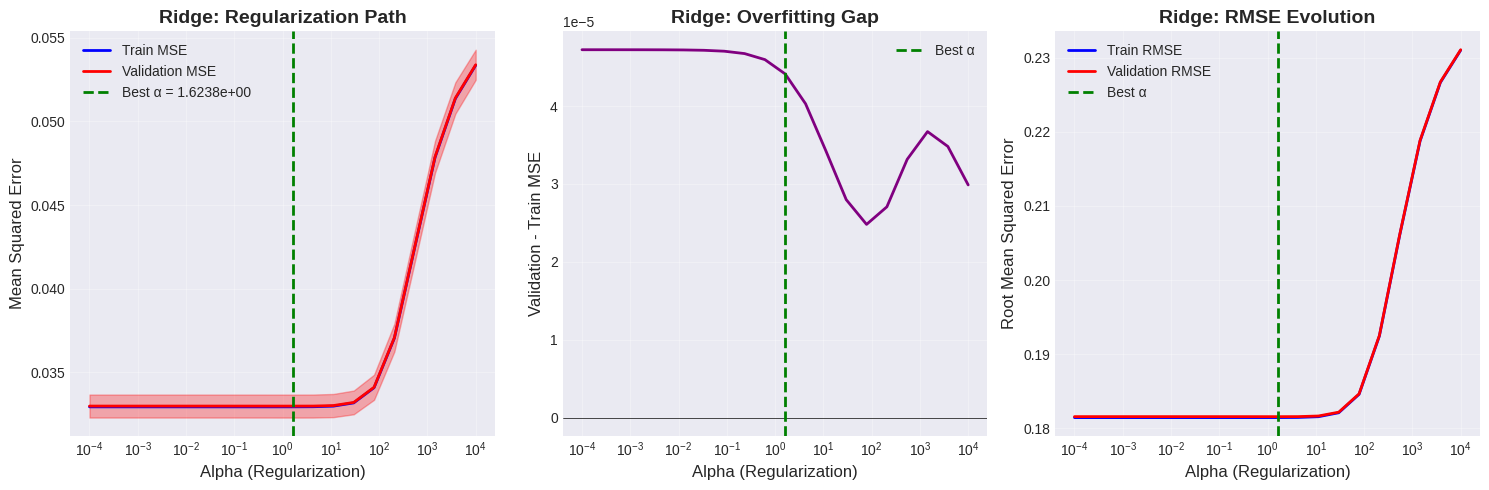

✅ Saved: ./results/plots/ridge_regularization_analysis.png

📈 Plot 2: Random Forest Hyperparameter Analysis


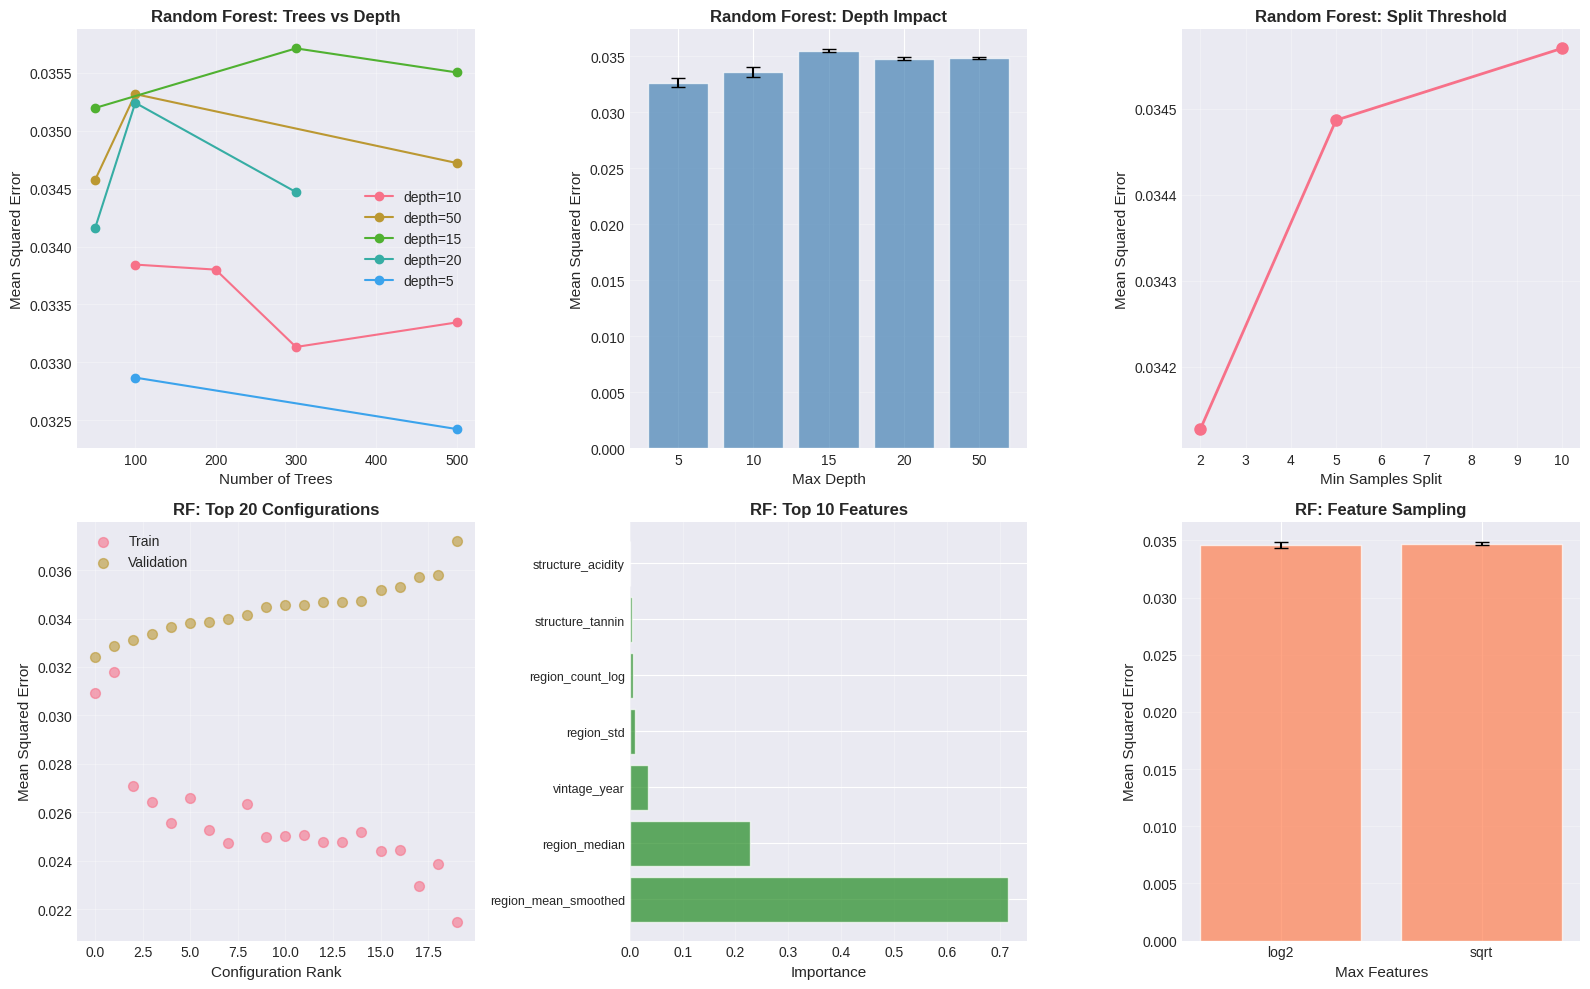

✅ Saved: ./results/plots/random_forest_analysis.png

📈 Plot 3: XGBoost Hyperparameter Analysis


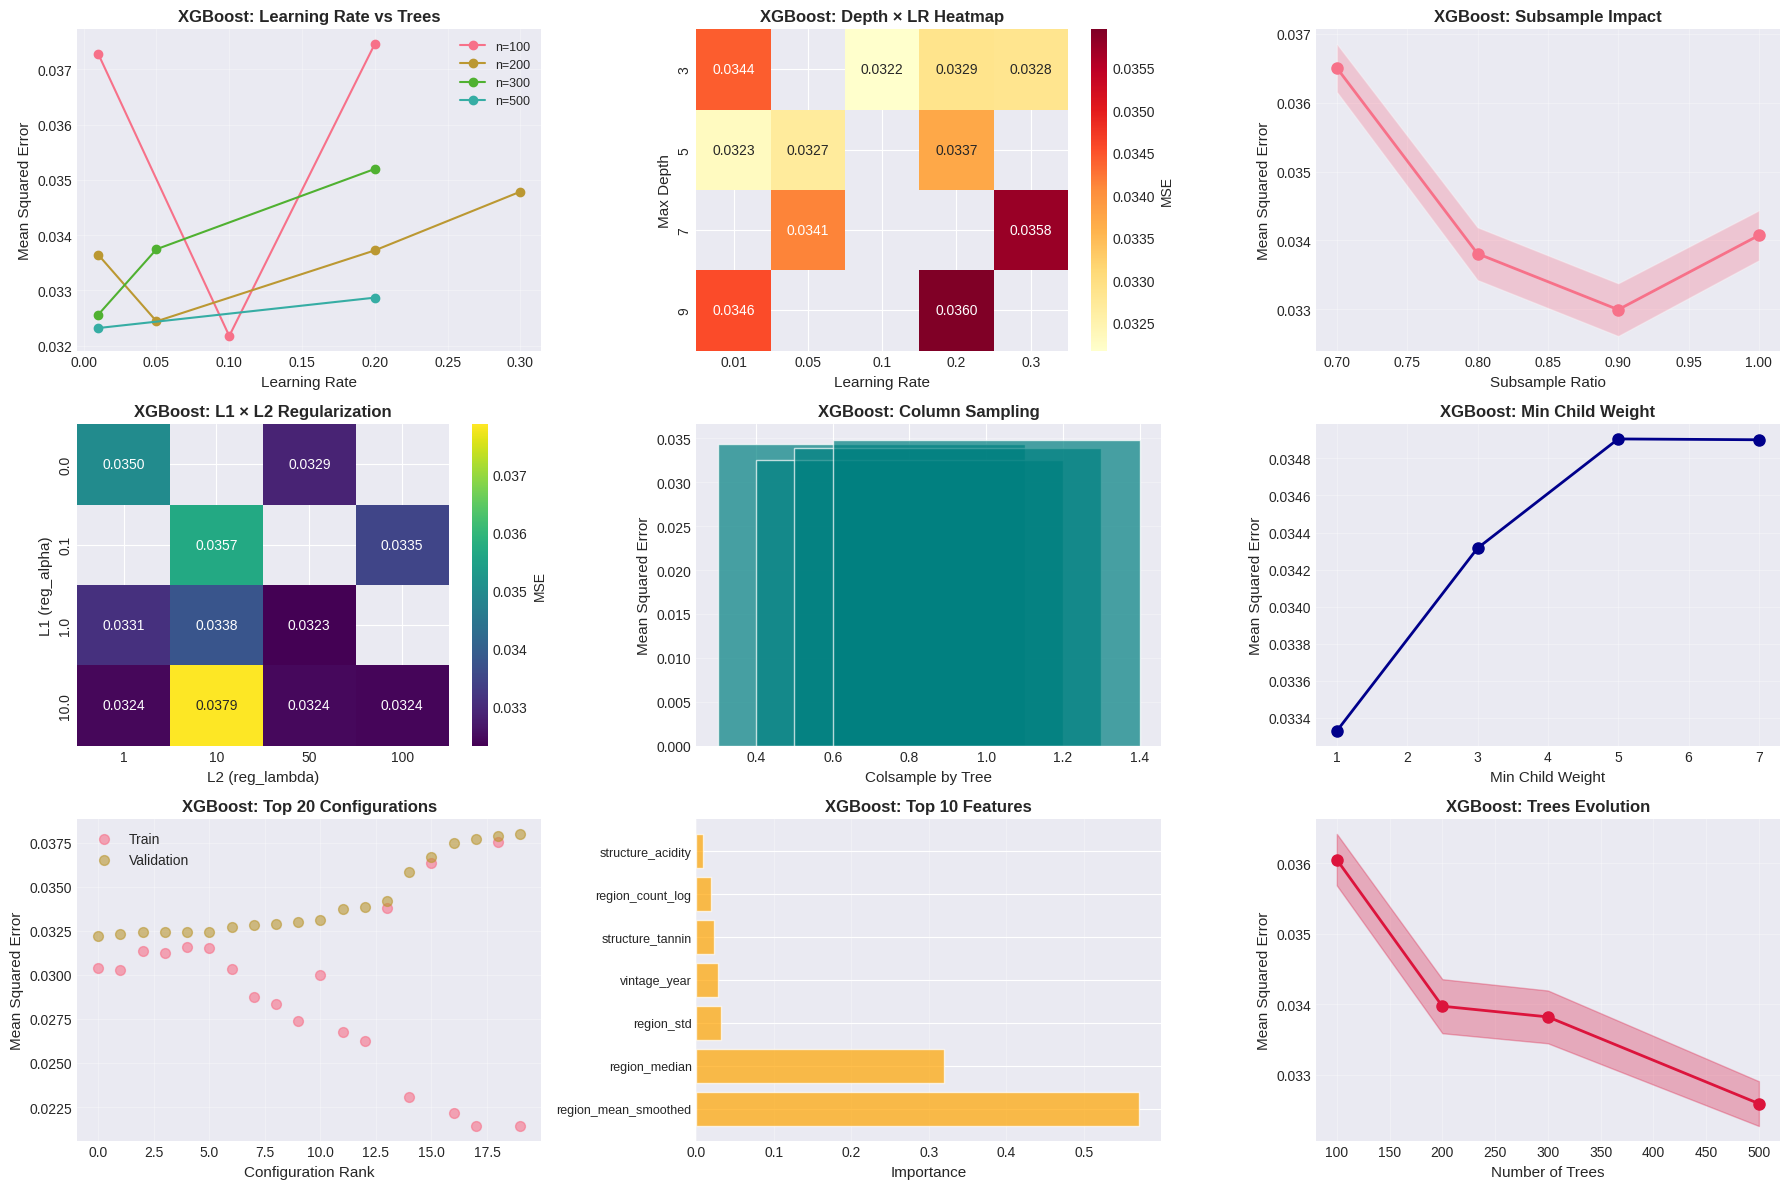

✅ Saved: ./results/plots/xgboost_analysis.png

📈 Plot 4: Overall Model Comparison


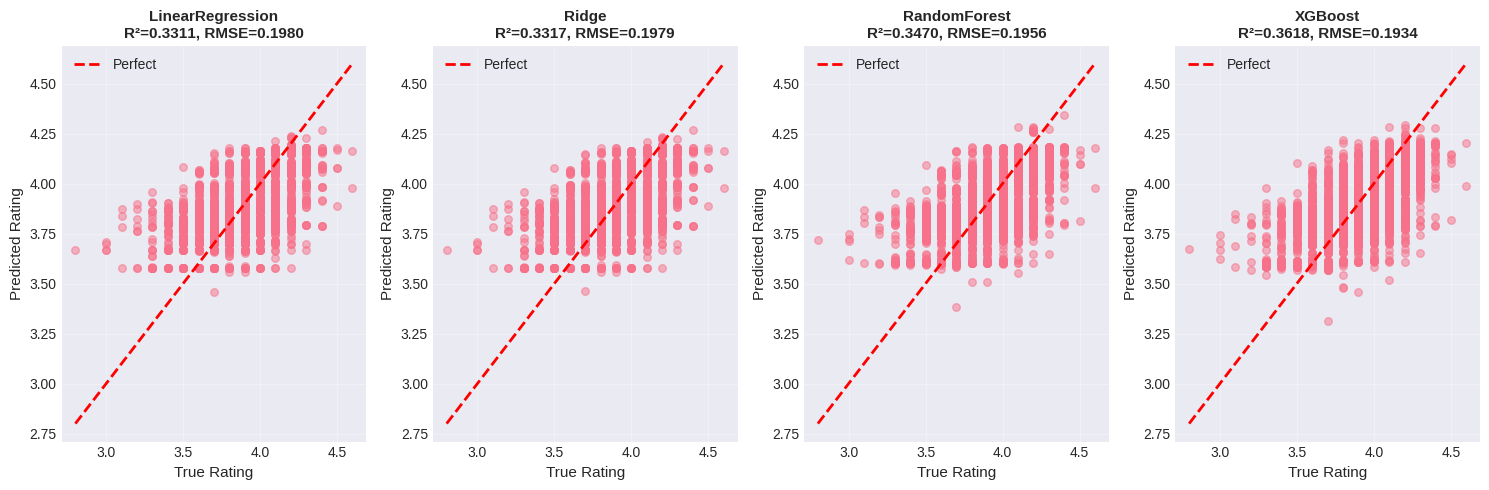

✅ Saved: ./results/plots/model_comparison_predictions.png


In [5]:

# ============================================================================
# 4. VISUALIZATION - HYPERPARAMETER ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("📊 Creating Hyperparameter Visualizations")
print("=" * 80)


os.makedirs('./results/plots', exist_ok=True)

# --- PLOT 1: Ridge Regularization Path ---
print("\n📈 Plot 1: Ridge Regularization Analysis")

fig = plt.figure(figsize=(15, 5))
gs = GridSpec(1, 3, figure=fig)

# Extract results
cv_results = grid_results['Ridge']
alphas = ridge_alphas
mean_train = -cv_results['mean_train_score']
mean_test = -cv_results['mean_test_score']
std_test = cv_results['std_test_score']

# Plot 1a: Train vs Test scores
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogx(alphas, mean_train, 'b-', label='Train MSE', linewidth=2)
ax1.semilogx(alphas, mean_test, 'r-', label='Validation MSE', linewidth=2)
ax1.fill_between(alphas, mean_test - std_test, mean_test + std_test,
                  alpha=0.3, color='red')
ax1.axvline(ridge_grid.best_params_['alpha'], color='g', linestyle='--',
            label=f'Best α = {ridge_grid.best_params_["alpha"]:.4e}', linewidth=2)
ax1.set_xlabel('Alpha (Regularization)', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Ridge: Regularization Path', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 1b: Overfitting analysis
ax2 = fig.add_subplot(gs[0, 1])
gap = mean_test - mean_train
ax2.semilogx(alphas, gap, 'purple', linewidth=2)
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax2.axvline(ridge_grid.best_params_['alpha'], color='g', linestyle='--',
            label='Best α', linewidth=2)
ax2.set_xlabel('Alpha (Regularization)', fontsize=12)
ax2.set_ylabel('Validation - Train MSE', fontsize=12)
ax2.set_title('Ridge: Overfitting Gap', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 1c: RMSE comparison
ax3 = fig.add_subplot(gs[0, 2])
rmse_train = np.sqrt(mean_train)
rmse_test = np.sqrt(mean_test)
ax3.semilogx(alphas, rmse_train, 'b-', label='Train RMSE', linewidth=2)
ax3.semilogx(alphas, rmse_test, 'r-', label='Validation RMSE', linewidth=2)
ax3.axvline(ridge_grid.best_params_['alpha'], color='g', linestyle='--',
            label='Best α', linewidth=2)
ax3.set_xlabel('Alpha (Regularization)', fontsize=12)
ax3.set_ylabel('Root Mean Squared Error', fontsize=12)
ax3.set_title('Ridge: RMSE Evolution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/plots/ridge_regularization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ./results/plots/ridge_regularization_analysis.png")
plt.close()

# --- PLOT 2: Random Forest Parameter Analysis ---
print("\n📈 Plot 2: Random Forest Hyperparameter Analysis")

cv_results_rf = grid_results['RandomForest']
results_df_rf = pd.DataFrame(cv_results_rf)

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig)

# Plot 2a: n_estimators effect
ax1 = fig.add_subplot(gs[0, 0])
for depth in results_df_rf['param_max_depth'].unique():
    if pd.notna(depth):
        mask = results_df_rf['param_max_depth'] == depth
        subset = results_df_rf[mask].groupby('param_n_estimators')['mean_test_score'].mean()
        ax1.plot(subset.index, -subset.values, marker='o', label=f'depth={depth}')
ax1.set_xlabel('Number of Trees', fontsize=11)
ax1.set_ylabel('Mean Squared Error', fontsize=11)
ax1.set_title('Random Forest: Trees vs Depth', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2b: max_depth effect
ax2 = fig.add_subplot(gs[0, 1])
depth_perf = results_df_rf.groupby('param_max_depth').agg({
    'mean_test_score': 'mean',
    'std_test_score': 'mean'
})
depths = [str(d) if pd.notna(d) else 'None' for d in depth_perf.index]
ax2.bar(depths, -depth_perf['mean_test_score'], yerr=depth_perf['std_test_score'],
        capsize=5, alpha=0.7, color='steelblue')
ax2.set_xlabel('Max Depth', fontsize=11)
ax2.set_ylabel('Mean Squared Error', fontsize=11)
ax2.set_title('Random Forest: Depth Impact', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 2c: min_samples_split effect
ax3 = fig.add_subplot(gs[0, 2])
split_perf = results_df_rf.groupby('param_min_samples_split')['mean_test_score'].mean()
ax3.plot(split_perf.index, -split_perf.values, marker='o', linewidth=2, markersize=8)
ax3.set_xlabel('Min Samples Split', fontsize=11)
ax3.set_ylabel('Mean Squared Error', fontsize=11)
ax3.set_title('Random Forest: Split Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 2d: Train vs Validation
ax4 = fig.add_subplot(gs[1, 0])
top_n = 20
top_configs = results_df_rf.nsmallest(top_n, 'rank_test_score')
x_pos = np.arange(top_n)
ax4.scatter(x_pos, -top_configs['mean_train_score'], label='Train', alpha=0.6, s=50)
ax4.scatter(x_pos, -top_configs['mean_test_score'], label='Validation', alpha=0.6, s=50)
ax4.set_xlabel('Configuration Rank', fontsize=11)
ax4.set_ylabel('Mean Squared Error', fontsize=11)
ax4.set_title(f'RF: Top {top_n} Configurations', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 2e: Feature importance from best model
ax5 = fig.add_subplot(gs[1, 1])
if hasattr(models['RandomForest'], 'feature_importances_'):
    importances = models['RandomForest'].feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    ax5.barh(range(len(indices)), importances[indices], alpha=0.7, color='forestgreen')
    ax5.set_yticks(range(len(indices)))
    ax5.set_yticklabels([feature_names[i] for i in indices], fontsize=9)
    ax5.set_xlabel('Importance', fontsize=11)
    ax5.set_title('RF: Top 10 Features', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')

# Plot 2f: max_features effect
ax6 = fig.add_subplot(gs[1, 2])
features_perf = results_df_rf.groupby('param_max_features').agg({
    'mean_test_score': 'mean',
    'std_test_score': 'mean'
})
ax6.bar(features_perf.index.astype(str), -features_perf['mean_test_score'],
        yerr=features_perf['std_test_score'], capsize=5, alpha=0.7, color='coral')
ax6.set_xlabel('Max Features', fontsize=11)
ax6.set_ylabel('Mean Squared Error', fontsize=11)
ax6.set_title('RF: Feature Sampling', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()#'./results/plots/random_forest_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: ./results/plots/random_forest_analysis.png")
plt.close()

# --- PLOT 3: XGBoost Parameter Analysis ---
print("\n📈 Plot 3: XGBoost Hyperparameter Analysis")

cv_results_xgb = grid_results['XGBoost']
results_df_xgb = pd.DataFrame(cv_results_xgb)

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig)

# Plot 3a: Learning rate effect
ax1 = fig.add_subplot(gs[0, 0])
for n_est in sorted(results_df_xgb['param_n_estimators'].unique()):
    mask = results_df_xgb['param_n_estimators'] == n_est
    subset = results_df_xgb[mask].groupby('param_learning_rate')['mean_test_score'].mean()
    ax1.plot(subset.index, -subset.values, marker='o', label=f'n={n_est}')
ax1.set_xlabel('Learning Rate', fontsize=11)
ax1.set_ylabel('Mean Squared Error', fontsize=11)
ax1.set_title('XGBoost: Learning Rate vs Trees', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 3b: Max depth effect
ax2 = fig.add_subplot(gs[0, 1])
depth_lr = results_df_xgb.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_learning_rate',
    aggfunc='mean'
)
sns.heatmap(-depth_lr, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'MSE'})
ax2.set_xlabel('Learning Rate', fontsize=11)
ax2.set_ylabel('Max Depth', fontsize=11)
ax2.set_title('XGBoost: Depth × LR Heatmap', fontsize=12, fontweight='bold')

# Plot 3c: Subsample effect
ax3 = fig.add_subplot(gs[0, 2])
subsample_perf = results_df_xgb.groupby('param_subsample').agg({
    'mean_test_score': 'mean',
    'std_test_score': 'mean'
})
ax3.plot(subsample_perf.index, -subsample_perf['mean_test_score'],
         marker='o', linewidth=2, markersize=8)
ax3.fill_between(subsample_perf.index,
                  -(subsample_perf['mean_test_score'] - subsample_perf['std_test_score']),
                  -(subsample_perf['mean_test_score'] + subsample_perf['std_test_score']),
                  alpha=0.3)
ax3.set_xlabel('Subsample Ratio', fontsize=11)
ax3.set_ylabel('Mean Squared Error', fontsize=11)
ax3.set_title('XGBoost: Subsample Impact', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 3d: Regularization (L1 vs L2)
ax4 = fig.add_subplot(gs[1, 0])
reg_pivot = results_df_xgb.pivot_table(
    values='mean_test_score',
    index='param_reg_alpha',
    columns='param_reg_lambda',
    aggfunc='mean'
)
sns.heatmap(-reg_pivot, annot=True, fmt='.4f', cmap='viridis', ax=ax4, cbar_kws={'label': 'MSE'})
ax4.set_xlabel('L2 (reg_lambda)', fontsize=11)
ax4.set_ylabel('L1 (reg_alpha)', fontsize=11)
ax4.set_title('XGBoost: L1 × L2 Regularization', fontsize=12, fontweight='bold')

# Plot 3e: colsample_bytree effect
ax5 = fig.add_subplot(gs[1, 1])
colsample_perf = results_df_xgb.groupby('param_colsample_bytree')['mean_test_score'].mean()
ax5.bar(colsample_perf.index, -colsample_perf.values, alpha=0.7, color='teal')
ax5.set_xlabel('Colsample by Tree', fontsize=11)
ax5.set_ylabel('Mean Squared Error', fontsize=11)
ax5.set_title('XGBoost: Column Sampling', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 3f: min_child_weight effect
ax6 = fig.add_subplot(gs[1, 2])
child_weight_perf = results_df_xgb.groupby('param_min_child_weight')['mean_test_score'].mean()
ax6.plot(child_weight_perf.index, -child_weight_perf.values,
         marker='o', linewidth=2, markersize=8, color='darkblue')
ax6.set_xlabel('Min Child Weight', fontsize=11)
ax6.set_ylabel('Mean Squared Error', fontsize=11)
ax6.set_title('XGBoost: Min Child Weight', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# Plot 3g: Top configurations comparison
ax7 = fig.add_subplot(gs[2, 0])
top_n = 20
top_configs = results_df_xgb.nsmallest(top_n, 'rank_test_score')
x_pos = np.arange(top_n)
ax7.scatter(x_pos, -top_configs['mean_train_score'], label='Train', alpha=0.6, s=50)
ax7.scatter(x_pos, -top_configs['mean_test_score'], label='Validation', alpha=0.6, s=50)
ax7.set_xlabel('Configuration Rank', fontsize=11)
ax7.set_ylabel('Mean Squared Error', fontsize=11)
ax7.set_title(f'XGBoost: Top {top_n} Configurations', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Plot 3h: Feature importance
ax8 = fig.add_subplot(gs[2, 1])
if hasattr(models['XGBoost'], 'feature_importances_'):
    importances = models['XGBoost'].feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    ax8.barh(range(len(indices)), importances[indices], alpha=0.7, color='orange')
    ax8.set_yticks(range(len(indices)))
    ax8.set_yticklabels([feature_names[i] for i in indices], fontsize=9)
    ax8.set_xlabel('Importance', fontsize=11)
    ax8.set_title('XGBoost: Top 10 Features', fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='x')

# Plot 3i: n_estimators evolution
ax9 = fig.add_subplot(gs[2, 2])
n_est_perf = results_df_xgb.groupby('param_n_estimators').agg({
    'mean_test_score': 'mean',
    'std_test_score': 'mean'
})
ax9.plot(n_est_perf.index, -n_est_perf['mean_test_score'],
         marker='o', linewidth=2, markersize=8, color='crimson')
ax9.fill_between(n_est_perf.index,
                  -(n_est_perf['mean_test_score'] - n_est_perf['std_test_score']),
                  -(n_est_perf['mean_test_score'] + n_est_perf['std_test_score']),
                  alpha=0.3, color='crimson')
ax9.set_xlabel('Number of Trees', fontsize=11)
ax9.set_ylabel('Mean Squared Error', fontsize=11)
ax9.set_title('XGBoost: Trees Evolution', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()#'./results/plots/xgboost_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: ./results/plots/xgboost_analysis.png")
plt.close()

# --- PLOT 4: Model Comparison Summary ---
print("\n📈 Plot 4: Overall Model Comparison")

fig = plt.figure(figsize=(15, 5))

# Predictions vs Actual for all models
for idx, (model_name, model) in enumerate(models.items()):
    ax = plt.subplot(1, len(models), idx + 1)
    y_pred = model.predict(X_val)

    ax.scatter(y_val, y_pred, alpha=0.5, s=30)

    # Perfect prediction line
    min_val = min(y_val.min(), y_pred.min())
    max_val = max(y_val.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')

    # Calculate R²
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    ax.set_xlabel('True Rating', fontsize=11)
    ax.set_ylabel('Predicted Rating', fontsize=11)
    ax.set_title(f'{model_name}\nR²={r2:.4f}, RMSE={rmse:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/plots/model_comparison_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ./results/plots/model_comparison_predictions.png")
plt.close()


In [6]:

# ============================================================================
# 5. COMPARISON & SELECTION
# ============================================================================
print("\n" + "=" * 80)
print("🏆 Model Comparison")
print("=" * 80)

results_df = pd.DataFrame(results).sort_values('rmse')
print("\n" + results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
best_rmse = results_df.iloc[0]['rmse']

print(f"\n🎯 Best Model: {best_model_name}")
print(f"   Validation RMSE: {best_rmse:.4f}")

# ============================================================================
# 6. FINAL TEST EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("🎯 FINAL TEST SET EVALUATION")
print("=" * 80)

test_metrics = evaluate(y_test, best_model.predict(X_test), f"{best_model_name} (TEST)")

print(f"\n📊 Validation vs Test:")
print(f"   Val RMSE:  {best_rmse:.4f}")
print(f"   Test RMSE: {test_metrics['rmse']:.4f}")
print(f"   Δ RMSE:    {abs(test_metrics['rmse'] - best_rmse):.4f}")

# ============================================================================
# 7. SAVE ARTIFACTS
# ============================================================================
print("\n" + "=" * 80)
print("💾 Saving Artifacts")
print("=" * 80)

os.makedirs('./models/trained', exist_ok=True)
os.makedirs('./results', exist_ok=True)

# Save best model
joblib.dump(best_model, './models/trained/best_model_te.pkl')
print(f"✅ Best model saved: ./models/trained/best_model_te.pkl")

# Save all models
for name, model in models.items():
    joblib.dump(model, f'./models/trained/{name}_te.pkl')
print(f"✅ All models saved to: ./models/trained/*_te.pkl")

# Save results
results_df.to_csv('./results/model_comparison_te.csv', index=False)
print(f"✅ Results saved: ./results/model_comparison_te.csv")

# Save grid search results
for name, cv_results in grid_results.items():
    pd.DataFrame(cv_results).to_csv(f'./results/{name}_grid_search_results.csv', index=False)
print(f"✅ Grid search results saved: ./results/*_grid_search_results.csv")

# Save metadata
metadata_output = {
    'encoding_type': 'advanced_target_encoding',
    'best_model': best_model_name,
    'best_hyperparameters': str(models[best_model_name].get_params()) if hasattr(models[best_model_name], 'get_params') else 'N/A',
    'validation_rmse': best_rmse,
    'validation_mae': results_df.iloc[0]['mae'],
    'test_rmse': test_metrics['rmse'],
    'test_mae': test_metrics['mae'],
    'validation_r2': results_df.iloc[0]['r2'],
    'test_r2': test_metrics['r2'],
    'features': feature_names,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('./results/model_metadata_te.json', 'w') as f:
    json.dump(metadata_output, f, indent=2)
print(f"✅ Metadata saved: ./results/model_metadata_te.json")

# ============================================================================
# 8. SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("✅ COMPLETED")
print("=" * 80)
print(f"⏰ Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n🎯 Best Model: {best_model_name}")
print(f"   Val RMSE:  {best_rmse:.4f}")
print(f"   Val MAE:   {results_df.iloc[0]['mae']:.4f}")
print(f"   Val R²:    {results_df.iloc[0]['r2']:.4f}")
print(f"   Test RMSE: {test_metrics['rmse']:.4f}")
print(f"   Test MAE:  {test_metrics['mae']:.4f}")
print(f"   Test R²:   {test_metrics['r2']:.4f}")
print("\n📊 Visualizations created:")
print("   - Ridge regularization analysis")
print("   - Random Forest hyperparameter analysis")
print("   - XGBoost hyperparameter analysis")
print("   - Model comparison predictions")
print("=" * 80)


🏆 Model Comparison

           model     rmse      mae       r2      time
         XGBoost 0.193358 0.150244 0.361775  6.120558
    RandomForest 0.195584 0.152469 0.346995 40.072496
           Ridge 0.197868 0.154296 0.331654  3.538903
LinearRegression 0.197956 0.154336 0.331059  0.001972

🎯 Best Model: XGBoost
   Validation RMSE: 0.1934

🎯 FINAL TEST SET EVALUATION

XGBoost (TEST):
  RMSE: 0.1891
  MAE:  0.1460
  R²:   0.3394

📊 Validation vs Test:
   Val RMSE:  0.1934
   Test RMSE: 0.1891
   Δ RMSE:    0.0043

💾 Saving Artifacts
✅ Best model saved: ./models/trained/best_model_te.pkl
✅ All models saved to: ./models/trained/*_te.pkl
✅ Results saved: ./results/model_comparison_te.csv
✅ Grid search results saved: ./results/*_grid_search_results.csv
✅ Metadata saved: ./results/model_metadata_te.json

✅ COMPLETED
⏰ Finished: 2025-11-14 15:58:41

🎯 Best Model: XGBoost
   Val RMSE:  0.1934
   Val MAE:   0.1502
   Val R²:    0.3618
   Test RMSE: 0.1891
   Test MAE:  0.1460
   Test R²:   0.33

✅ Figure saved: /mnt/user-data/outputs/model_comparison_simple.png


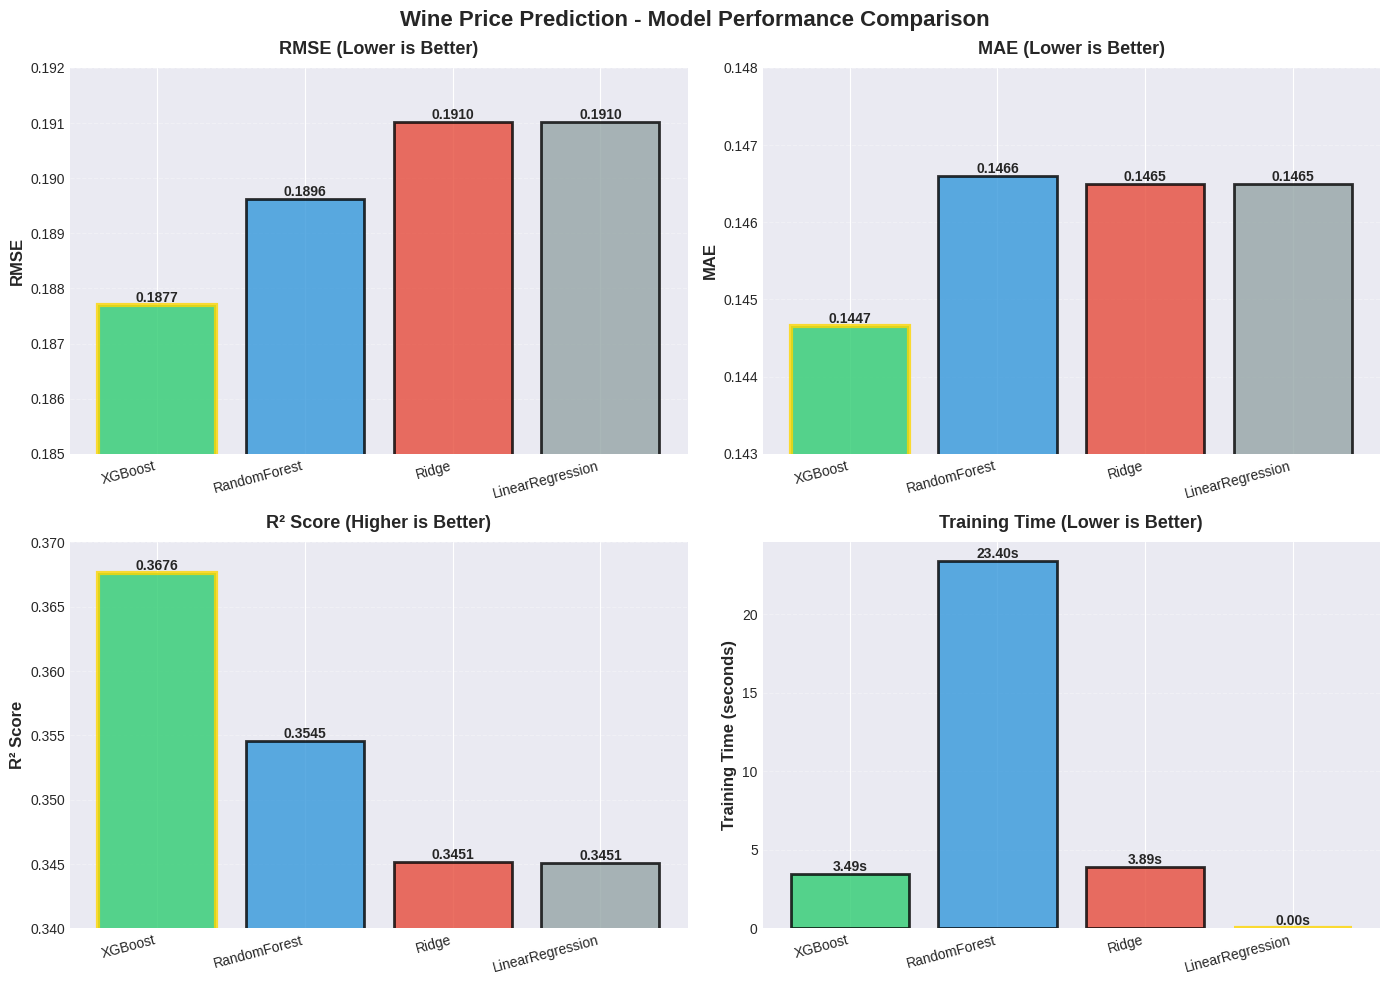


📊 Simple Model Comparison Chart Created!
4 panels showing:
  1. RMSE - Root Mean Squared Error
  2. MAE  - Mean Absolute Error
  3. R²   - Coefficient of Determination
  4. Time - Training Time

🏆 Best model: XGBoost (highlighted with gold border)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Model results data
results_data = {
    'Model': ['XGBoost', 'RandomForest', 'Ridge', 'LinearRegression'],
    'RMSE': [0.187703, 0.189631, 0.191010, 0.191017],
    'MAE': [0.144656, 0.146595, 0.146490, 0.146491],
    'R²': [0.367595, 0.354540, 0.345118, 0.345069],
    'Time (s)': [3.487472, 23.399068, 3.890569, 0.004157]
}

df = pd.DataFrame(results_data)

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wine Price Prediction - Model Performance Comparison',
             fontsize=16, fontweight='bold', y=0.98)

# Color palette
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

# 1. RMSE
ax1 = axes[0, 0]
bars = ax1.bar(df['Model'], df['RMSE'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('RMSE (Lower is Better)', fontsize=13, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.185, 0.192])

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight best
best_idx = df['RMSE'].idxmin()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

# 2. MAE
ax2 = axes[0, 1]
bars = ax2.bar(df['Model'], df['MAE'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE (Lower is Better)', fontsize=13, fontweight='bold', pad=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0.143, 0.148])

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight best
best_idx = df['MAE'].idxmin()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

# 3. R²
ax3 = axes[1, 0]
bars = ax3.bar(df['Model'], df['R²'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax3.set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim([0.34, 0.37])

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight best
best_idx = df['R²'].idxmax()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

# 4. Training Time
ax4 = axes[1, 1]
bars = ax4.bar(df['Model'], df['Time (s)'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('Training Time (Lower is Better)', fontsize=13, fontweight='bold', pad=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight best
best_idx = df['Time (s)'].idxmin()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

# Rotate x-axis labels for better readability
for ax in axes.flat:
    ax.set_xticklabels(df['Model'], rotation=15, ha='right')
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()

# Save figure
output_path = '/mnt/user-data/outputs/model_comparison_simple.png'
plt.savefig('./results/plots/model_comparison_simple.png', dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_path}")

plt.show()

print("\n" + "="*80)
print("📊 Simple Model Comparison Chart Created!")
print("="*80)
print("4 panels showing:")
print("  1. RMSE - Root Mean Squared Error")
print("  2. MAE  - Mean Absolute Error")
print("  3. R²   - Coefficient of Determination")
print("  4. Time - Training Time")
print("\n🏆 Best model: XGBoost (highlighted with gold border)")
print("="*80)